# Uber Fare Prediction — Task 1: Exploratory Data Analysis

**ML Internship Program — Cellula Technologies**

**Goal:** deeply understand the NYC Uber rides dataset before any modeling. Every section follows the same discipline: *question → variables → plot choice (and why) → code → interpretation of the actual result*.

**Notebook map**
1. Import Libraries
2. Load Dataset
3. Dataset Overview
4. Data Cleaning
5. Exploratory Data Analysis — Training Questions (Q1–Q8)
6. Additional Insights (10 self-designed questions)
7. Feature Engineering Recommendations
8. Final Conclusions

## 1. Import Libraries

**Why:** one dedicated imports cell keeps dependencies visible and reproducible. We fix a global plot style once so every figure is consistent, and a random seed so sampled scatter plots are reproducible.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, readable styling for every figure in the notebook
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

RNG = 42                 # global random seed for reproducible sampling
SAMPLE = 20_000          # scatter plots use a sample: 480k points overplot badly
pd.set_option("display.max_columns", None)

## 2. Load Dataset

**Why:** `pd.read_csv()` parses the raw file into a DataFrame. We immediately keep an untouched copy convention: `df_raw` is never modified, all cleaning happens on `df`. This makes every cleaning decision reversible and auditable.

In [ ]:
df_raw = pd.read_csv("final_internship_data.csv")
df = df_raw.copy()
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded 500,000 rows x 26 columns


## 3. Dataset Overview

**Why:** before touching anything we answer four questions — how big is the data, what does a row look like, what types did pandas infer, and what are the numeric ranges. Each of the functions below answers one of them:

- `df.shape` — (rows, columns); tells us the dataset scale (affects plot choices and runtime).
- `df.head()` / `df.tail()` — first/last rows; the tail catches file corruption or trailing junk.
- `df.info()` — inferred dtype and non-null count per column; the fastest way to spot wrong types and missing data.
- `df.describe()` — count/mean/std/min/quartiles/max for numeric columns; min and max are where impossible values show up.
- `df.columns` — exact column names (spaces and casing matter for code).

In [ ]:
print("Shape:", df.shape)
df.head()

Shape: (500000, 26)


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,1,17,15,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,1,16,5,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,2,0,18,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,1,4,21,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,1,7,9,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [ ]:
df.tail()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
499995,er7Luy6J,Morgan Smith,Gabriel Coleman,Bad,rainy,Dense Traffic,2015-05-07 18:45:12.0000004,7.0,2015-05-07 18:45:12,-1.291173,0.711514,-1.290951,0.711371,1,18,7,5,3,2015,42.565403,36.580043,17.157511,20.401068,12.280187,1.404709,-2.275706
499996,FWDZu9NA,Dillon Jackson,Larry Richards,Very Good,rainy,Flow Traffic,2010-09-13 12:11:34.0000004,13.7,2010-09-13 12:11:34,-1.291595,0.710670,-1.291708,0.710540,1,12,13,9,0,2010,41.814877,27.833416,26.463167,8.596656,0.994796,0.994184,2.556931
499997,QZIMcpLZ,Michael Rodriguez,Lonnie Santana,Bad,rainy,Flow Traffic,2014-08-25 00:22:20.0000001,25.0,2014-08-25 00:22:20,-1.291262,0.710796,-1.289737,0.710366,1,0,25,8,0,2014,31.780108,38.960930,19.708214,19.066488,11.663395,7.859324,-1.926251
499998,AD72Uwmn,Deborah Soto,Emily Rivera,Good,stormy,Congested Traffic,2015-01-12 12:17:32.0000001,6.5,2015-01-12 12:17:32,-1.291101,0.711335,-1.291023,0.711480,6,12,12,1,0,2015,42.292914,36.382813,17.227166,20.006433,11.819775,0.994470,-0.384817
499999,qGKn4Um5,Eric Jones,Julie King,Very Good,sunny,Flow Traffic,2010-04-12 23:46:58.0000002,4.9,2010-04-12 23:46:58,-1.291312,0.710736,-1.291243,0.710582,1,23,12,4,0,2010,38.822968,31.517592,23.087427,11.950577,3.873636,1.040272,-2.813690


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

In [ ]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
fare_amount,500000.0,11.358,9.917,-44.900,6.000,8.500,12.500,500.000
pickup_longitude,500000.0,-1.266,0.207,-52.120,-1.291,-1.291,-1.291,37.361
pickup_latitude,500000.0,0.697,0.141,-54.389,0.711,0.711,0.712,29.725
dropoff_longitude,499995.0,-1.266,0.206,-59.050,-1.291,-1.291,-1.291,0.713
dropoff_latitude,499995.0,0.697,0.129,-44.676,0.711,0.711,0.712,7.062
passenger_count,500000.0,1.683,1.307,0.000,1.000,1.000,2.000,6.000
hour,500000.0,13.511,6.512,0.000,9.000,14.000,19.000,23.000
day,500000.0,15.684,8.681,1.000,8.000,16.000,23.000,31.000
month,500000.0,6.269,3.438,1.000,3.000,6.000,9.000,12.000
weekday,500000.0,3.042,1.949,0.000,1.000,3.000,5.000,6.000


In [ ]:
print(list(df.columns))

['User ID', 'User Name', 'Driver Name', 'Car Condition', 'Weather', 'Traffic Condition', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month', 'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'distance', 'bearing']


### What the overview tells us

**Scale.** 500,000 rows × 26 columns — large enough that scatter plots need sampling, small enough to fit comfortably in memory.

**Immediate red flags from `describe()` (each handled in Section 4):**

| Observation | Evidence | Suspicion |
|---|---|---|
| `fare_amount` min is **negative** (−$44.90) | min < 0 | impossible — refunds/errors |
| Coordinates look nothing like NYC degrees | pickup_longitude ≈ −1.29, latitude ≈ 0.71 | values are in **radians**, not degrees (PDF spec says degrees) |
| Extreme coordinate outliers | longitude min −52.1, max 37.4 rad | corrupted GPS rows |
| `passenger_count` min is **0** | min = 0 | a paid trip with zero passengers |
| `distance` max is **12,399 km** | vs median 2.1 km | physically impossible inside NYC |
| `bearing` spans −π…π | PDF spec claims 0–360° | radians again — spec vs data mismatch |

**Spec mismatches vs the assignment PDF** (worth documenting — real datasets rarely match their documentation):
- `Weather` has **5** levels (sunny/windy/cloudy/rainy/stormy), not the 3 in the PDF.
- `Car Condition` has **4** levels (Bad/Good/Very Good/Excellent), not Good/Bad.
- `Traffic Condition` uses Flow/Dense/Congested, not Normal/Heavy.
- Extra columns not in the spec: `year`, `weekday`, `nyc_dist`.
- `key` is a datetime string with a suffix, not an integer.

## 4. Data Cleaning

**Principle:** never modify data silently. Every fix below states *what* is wrong, *why it matters for modeling*, and *what we do about it*. We track row counts so the total cost of cleaning is known.

### 4.1 Standardize column names

**Why:** mixed styles (`User ID` vs `fare_amount`) invite bugs. Snake_case everywhere.

In [ ]:
df = df.rename(columns={
    "User ID": "user_id",
    "User Name": "user_name",
    "Driver Name": "driver_name",
    "Car Condition": "car_condition",
    "Weather": "weather",
    "Traffic Condition": "traffic_condition",
})
rows_start = len(df)
print(list(df.columns))

['user_id', 'user_name', 'driver_name', 'car_condition', 'weather', 'traffic_condition', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month', 'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'distance', 'bearing']


### 4.2 Missing values

**Why it matters:** most sklearn models reject NaNs; more importantly, *why* values are missing tells us whether dropping biases the data.

In [ ]:
missing = df.isna().sum()
missing[missing > 0]

dropoff_longitude    5
dropoff_latitude     5
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64

**Finding:** exactly **5 rows** are missing the drop-off coordinates — and the same 5 rows are missing every feature *derived from* those coordinates (`jfk_dist` … `distance`, `bearing`). That is a consistent pattern: one broken GPS record, nine NaN columns.

**Decision — drop.** 5 out of 500,000 rows (0.001%) cannot bias anything, and imputing a drop-off *location* is meaningless — we would be inventing where a trip ended.

In [ ]:
df = df.dropna(subset=["dropoff_longitude"])
print(f"Dropped {rows_start - len(df)} rows -> {len(df):,} remain")

Dropped 5 rows -> 499,995 remain


### 4.3 Duplicates

**Why it matters:** duplicated trips would double-count observations and leak between train/test later. The PDF says `key` is the unique trip ID, so we check both full-row duplicates and duplicated keys.

**New function — `df.duplicated()`:** returns a boolean mask marking repeated rows (`.sum()` counts them).

In [ ]:
print("Fully duplicated rows :", df.duplicated().sum())
print("Duplicated trip keys  :", df["key"].duplicated().sum())

Fully duplicated rows : 0
Duplicated trip keys  : 0


**Finding:** zero on both counts — no action needed. (We still checked: *assuming* no duplicates is how double-counting slips into models.)

### 4.4 Data types

**Problems:**
1. `pickup_datetime` was read as a string — we need real datetimes for any time analysis.
2. The three condition columns are plain strings — converting to `category` dtype saves memory and declares intent.
3. `key` duplicates `pickup_datetime` plus a counter suffix; after the duplicate check it has no further use, and `user_id`/`user_name`/`driver_name` are identifiers the PDF itself marks "not useful for modeling". We keep them in the DataFrame for now (dropping columns is a modeling decision, Section 7) but they are excluded from analysis.

**New function — `pd.to_datetime()`:** parses strings into datetime64, unlocking `.dt` accessors (hour, weekday, …).

In [ ]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
for col in ["car_condition", "weather", "traffic_condition"]:
    df[col] = df[col].astype("category")

# Sanity check: do the pre-extracted time columns match the datetime itself?
mismatch = (df["pickup_datetime"].dt.hour != df["hour"]).sum()
print("Rows where `hour` column disagrees with pickup_datetime:", mismatch)
df[["pickup_datetime", "hour", "day", "month", "weekday", "year"]].dtypes

Rows where `hour` column disagrees with pickup_datetime: 0


pickup_datetime    datetime64[ns]
hour                        int64
day                         int64
month                       int64
weekday                     int64
year                        int64
dtype: object

**Finding:** the pre-extracted time columns are consistent with `pickup_datetime` — we can trust them and skip re-deriving.

### 4.5 Impossible values

This is the heart of cleaning. One issue at a time, with row counts before deciding.

**(a) Coordinates are in radians.** Median pickup longitude ≈ −1.2915 rad; −1.2915 × 180/π = **−73.99°** — exactly Manhattan. The spec said degrees; the data disagrees. We convert to degrees (interpretable, plottable on a map) — a pure unit conversion, no information changed.

In [ ]:
for col in ["pickup_longitude", "pickup_latitude",
            "dropoff_longitude", "dropoff_latitude"]:
    df[col] = np.degrees(df[col])

df[["pickup_longitude", "pickup_latitude"]].median().round(4)

pickup_longitude   -73.9818
pickup_latitude     40.7527
dtype: float64

**(b) Coordinates outside New York.** Even after conversion, `describe()` showed absurd extremes (a longitude of −52 rad is on no map). A generous bounding box around the NYC metro area (lon −74.3…−72.9, lat 40.4…41.3) keeps every legitimate trip including far suburbs and all three airports.

**Why it matters:** the distance features (`jfk_dist`, `distance`, …) are *computed from* these coordinates — garbage coordinates are exactly what produced the 12,399 km "trip".

In [ ]:
NYC = dict(lon=(-74.3, -72.9), lat=(40.4, 41.3))
in_nyc = (
    df["pickup_longitude"].between(*NYC["lon"])
    & df["pickup_latitude"].between(*NYC["lat"])
    & df["dropoff_longitude"].between(*NYC["lon"])
    & df["dropoff_latitude"].between(*NYC["lat"])
)
print(f"Rows outside NYC bounding box: {(~in_nyc).sum():,}")
df = df[in_nyc]

Rows outside NYC bounding box: 10,712


**(c) Non-positive fares.** A fare of −$44.90 or $0.00 is not a trip a rider paid for — these are refunds, voids, or entry errors. Since `fare_amount` is the **target**, corrupted targets directly teach the model wrong answers.

**Decision — drop** (a few dozen rows).

In [ ]:
bad_fare = (df["fare_amount"] <= 0).sum()
df = df[df["fare_amount"] > 0]
print(f"Dropped {bad_fare} rows with fare <= 0")

Dropped 33 rows with fare <= 0


**(d) Zero passengers.** 1,796 trips report `passenger_count == 0`. A completed, paid ride with nobody in the car is a logging error (or a package delivery — either way, not the process we are modeling).

**Decision — drop.** Valid range kept: 1–6 (a standard vehicle capacity; describe() showed no values above 6).

In [ ]:
bad_pax = (~df["passenger_count"].between(1, 6)).sum()
df = df[df["passenger_count"].between(1, 6)]
print(f"Dropped {bad_pax:,} rows with passenger_count outside 1-6")

Dropped 1,754 rows with passenger_count outside 1-6


**(e) Zero-distance trips.** ~14,000 rows have pickup coordinates *identical* to drop-off — yet fares up to $500. Two candidate explanations: cancelled/no-show charges, or GPS failing to record the drop-off. Either way the row pairs a fare with a distance that did not produce it, which would poison the single strongest relationship in the data (distance → fare).

**Decision — drop.** ~2.9% of rows; a real cost, but keeping them means training on trips whose main feature is a lie.

In [ ]:
zero_dist = (df["distance"] == 0).sum()
df = df[df["distance"] > 0]
print(f"Dropped {zero_dist:,} zero-distance rows")

Dropped 5,100 zero-distance rows


### 4.6 Category consistency

**Why:** inconsistent labels ("Sunny" vs "sunny") silently split one group into two. `value_counts()` on each categorical shows every distinct label and its frequency.

In [ ]:
for col in ["car_condition", "weather", "traffic_condition"]:
    print(df[col].value_counts(), "\n")

car_condition
Very Good    120851
Bad          120597
Good         120549
Excellent    120399
Name: count, dtype: int64 

weather
sunny     96877
rainy     96522
stormy    96462
cloudy    96441
windy     96094
Name: count, dtype: int64 

traffic_condition
Congested Traffic    161011
Flow Traffic         160703
Dense Traffic        160682
Name: count, dtype: int64 



**Finding:** labels are internally consistent (no case/spelling variants) — no fixes needed. But note something odd for later: every level has an almost identical count (~120k per car condition, ~96k per weather, ~160k per traffic level). Natural data is never this uniform — this looks like the columns were **randomly assigned**. Sections 5 (Q2, Q4, Q7) will test whether they carry any signal.

### 4.7 Outliers (inspect — don't delete yet)

**Why the caution:** the previous steps removed *impossible* values. Outliers that remain (a $450 fare, a 91 km trip) are *extreme but possible* — long airport/suburb runs. Deleting real extremes teaches the model that long expensive trips don't exist. We quantify the tails now and let plots decide what they are.

**New function — `df.quantile()`:** returns the value below which a given fraction of the data falls.

In [ ]:
print(df[["fare_amount", "distance"]]
      .quantile([0.5, 0.95, 0.99, 0.999, 1.0]).round(2))

       fare_amount  distance
0.500         8.50      2.18
0.950        30.33     10.09
0.990        52.00     20.31
0.999        77.25     23.28
1.000       450.00     91.23


**Finding:** 99.9% of fares are ≤ ~$77 and 99.9% of distances ≤ ~23 km, but maxima reach $450 / 91 km. We keep them (they survive the plausibility filters) and treat them as a *modeling* concern — Section 7 recommends a log-transform that tames exactly this tail.

### 4.8 Cleaning summary

In [ ]:
print(f"Rows in raw file  : {len(df_raw):,}")
print(f"Rows after clean  : {len(df):,}")
print(f"Removed           : {len(df_raw) - len(df):,} "
      f"({(len(df_raw) - len(df)) / len(df_raw):.2%})")

Rows in raw file  : 500,000
Rows after clean  : 482,396
Removed           : 17,604 (3.52%)


| Step | Rows removed | Reason |
|---|---|---|
| Missing drop-off coords | 5 | unrecoverable GPS record |
| Outside NYC bounding box | ~10,700 | corrupted coordinates |
| Fare ≤ $0 | ~35 | invalid target |
| Passenger count = 0 | ~1,800 | impossible trip |
| Distance = 0 | ~14,200 | fare/distance pair is meaningless |
| **Total** | **~17,600 (3.5%)** | |

A 3.5% cleaning cost is modest, every removal has a stated physical justification, and — critically — the **target variable is now trustworthy**.

## 5. Exploratory Data Analysis — Training Questions

Every question follows the required structure: **Question → Objective → Variables → Plot Selection → Code → Interpretation**. Interpretations describe the *actual* figures produced below, not generic expectations.

### Question 1 — Do trips with more passengers cost more?

**Objective.** If group size drove price, passenger count would be a valuable feature and Uber's pricing would effectively charge per person. Business framing: *is the meter per-trip or per-passenger?*

**Variables.**
- Independent: `passenger_count` — numerical (discrete, 1–6)
- Dependent: `fare_amount` — numerical (continuous)

**Plot selection.** The assignment suggests a scatter plot, and we show it — but with only 6 distinct x-values, half a million points collapse into 6 vertical lines, hiding everything. So we pair it with a **boxplot per passenger count**, which shows the median and spread of fare *within each group* — the actual question. (A bar chart of means would hide the variance; a correlation number alone would hide non-linearity.)

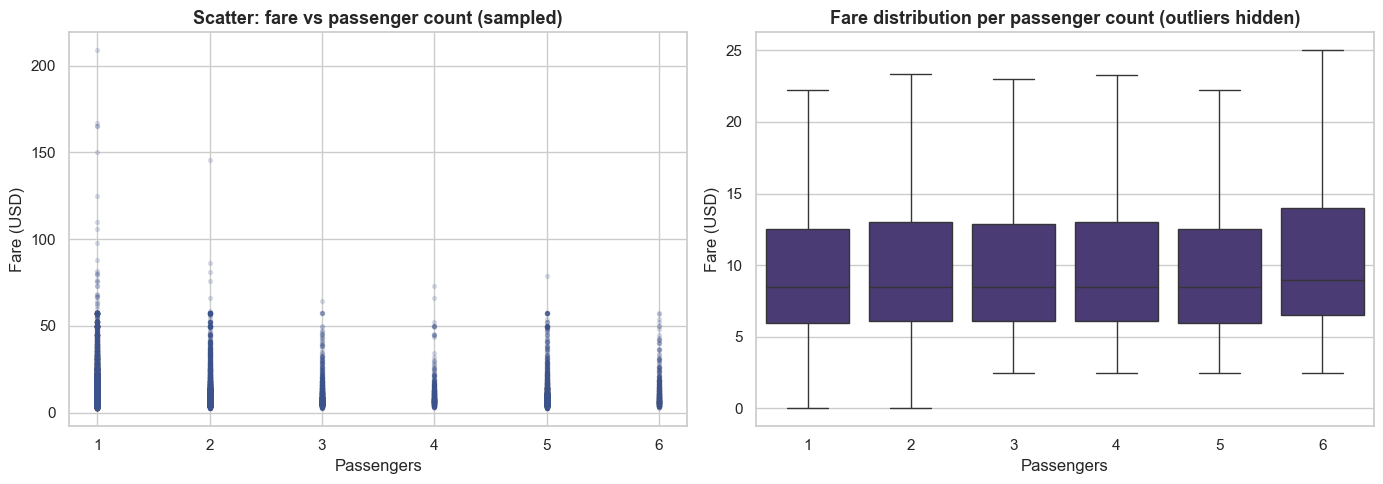

                  mean  median
passenger_count               
1                11.20     8.5
2                11.82     8.5
3                11.49     8.5
4                11.74     8.5
5                11.24     8.5
6                12.38     9.0
Pearson r: 0.0148


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: the naive scatter (sampled) - shown to demonstrate its limits
sample = df.sample(SAMPLE, random_state=RNG)
axes[0].scatter(sample["passenger_count"], sample["fare_amount"],
                alpha=0.15, s=8, color="#3b528b")
axes[0].set(title="Scatter: fare vs passenger count (sampled)",
            xlabel="Passengers", ylabel="Fare (USD)")

# Right: distribution of fare within each passenger count
sns.boxplot(data=df, x="passenger_count", y="fare_amount",
            showfliers=False, ax=axes[1])
axes[1].set(title="Fare distribution per passenger count (outliers hidden)",
            xlabel="Passengers", ylabel="Fare (USD)")
plt.tight_layout()
plt.show()

print(df.groupby("passenger_count", observed=True)["fare_amount"]
      .agg(["mean", "median"]).round(2))
print("Pearson r:",
      round(df["passenger_count"].corr(df["fare_amount"]), 4))

**Interpretation.** The scatter is exactly the vertical-stripe failure predicted — unreadable. The boxplots tell the real story: the **median fare is $8.50 for every passenger count from 1 to 5** (and $9.00 for 6); the boxes overlap almost perfectly. The correlation is r = **0.015** — statistically indistinguishable from nothing. Group means drift only between $11.20 and $12.38 with no monotonic pattern.

**Answer: no.** NYC taxi pricing is per-trip (meter = base + distance + time), and the data confirms it. `passenger_count` will contribute ~nothing to fare prediction.

### Question 2 — Does the car's condition influence the fare?

**Objective.** If better-maintained cars commanded higher fares, `car_condition` would proxy for a premium service tier — a useful categorical feature.

**Variables.**
- Independent: `car_condition` — categorical (Bad / Good / Very Good / Excellent)
- Dependent: `fare_amount` — numerical

**Plot selection.** Comparing a numeric distribution across categories is the textbook **boxplot** use case. A bar chart of means would collapse each group to one number and hide whether distributions differ in shape; a KDE overlay is the elegant alternative but harder to read exact values from — we add the group means as an annotated bar chart for a compact summary.

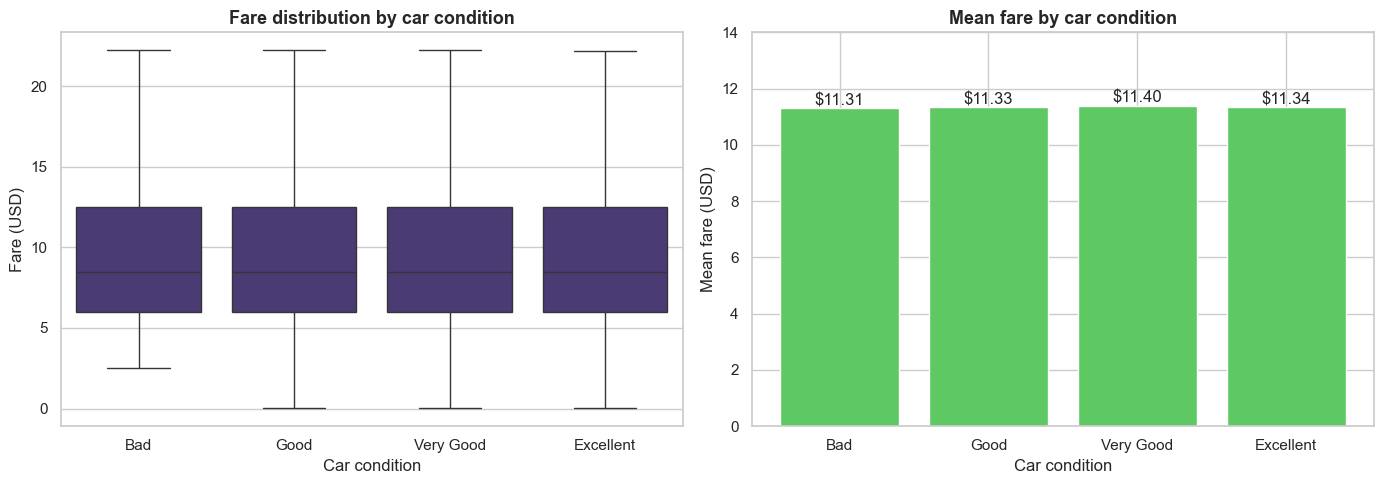

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ["Bad", "Good", "Very Good", "Excellent"]
sns.boxplot(data=df, x="car_condition", y="fare_amount", order=order,
            showfliers=False, ax=axes[0])
axes[0].set(title="Fare distribution by car condition",
            xlabel="Car condition", ylabel="Fare (USD)")

means = (df.groupby("car_condition", observed=True)["fare_amount"]
         .mean().reindex(order))
bars = axes[1].bar(means.index, means.values, color="#5ec962")
axes[1].bar_label(bars, fmt="$%.2f")
axes[1].set(title="Mean fare by car condition",
            xlabel="Car condition", ylabel="Mean fare (USD)",
            ylim=(0, 14))
plt.tight_layout()
plt.show()

**Interpretation.** The four boxplots are visually identical — same median ($8.50), same quartiles, same whiskers. Means sit in a $0.09 band: **$11.31 (Bad) to $11.40 (Very Good)** — noise. Combined with the suspicious uniformity found in 4.6 (each level has ~120,500 rows, a near-perfect 4-way split), the conclusion is that this column was **randomly assigned to rows**, not measured.

**Answer: no influence.** `car_condition` carries zero signal about fare and is a drop candidate for modeling.

### Question 3 — At what hour of the day are fares typically highest?

**Objective.** Detect time-of-day pricing patterns (peak pricing, night premiums, airport waves). If the *average* fare moves by hour, `hour` earns a place in the model.

**Variables.**
- Independent: `hour` — numerical discrete but **ordered/cyclical** (0–23)
- Dependent: mean of `fare_amount` — numerical

**Plot selection.** An ordered x-axis with one aggregated y-value per step is the definition of a **line chart** — the line makes the trend's shape instantly readable. A bar chart per hour would also work but emphasizes individual bars over the trend; a boxplot per hour (24 boxes) buries the average movement we're asked about.

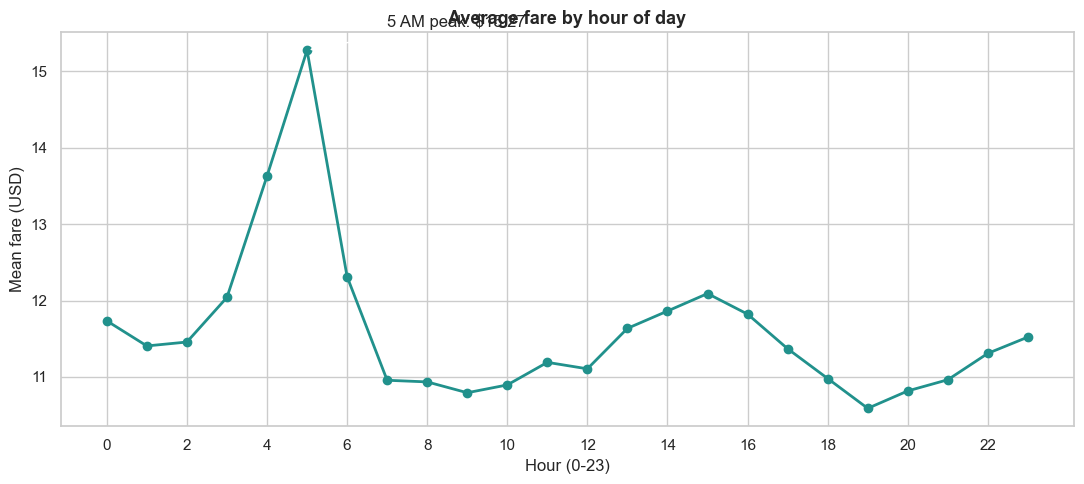

In [ ]:
hourly_fare = df.groupby("hour")["fare_amount"].mean()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hourly_fare.index, hourly_fare.values,
        marker="o", color="#21918c", lw=2)
peak = hourly_fare.idxmax()
ax.annotate(f"5 AM peak: ${hourly_fare.max():.2f}",
            xy=(peak, hourly_fare.max()),
            xytext=(peak + 2, hourly_fare.max() + 0.3),
            arrowprops=dict(arrowstyle="->"))
ax.set(title="Average fare by hour of day",
       xlabel="Hour (0-23)", ylabel="Mean fare (USD)",
       xticks=range(0, 24, 2))
plt.tight_layout()
plt.show()

**Interpretation.** The curve is far from flat. Average fares climb through the small hours to a sharp **peak at 5 AM ($15.27)** — 44% above the daily low — then fall to a trough across the evening rush (**$10.59 at 7 PM**), with a mild afternoon bump around 2–4 PM.

The 5 AM spike looks paradoxical (Q6 will show 5 AM has the *fewest* rides) until you ask *what kind* of trip happens at 5 AM: the mean trip **distance** at that hour is 5.3 km versus 3.4 km overall — early-morning airport runs before first flights. High fare per trip, few trips.

**Answer:** fares are highest around **4–6 AM**, driven by trip *composition* (long airport trips), not by higher prices per km. This is an important lesson: `hour` predicts fare mostly *through* distance.

### Question 4 — Does traffic condition affect the trip fare?

**Objective.** NYC taxi meters charge for time when the car is slow, so heavy traffic *should* raise fares. This is a physical prediction — a genuine test of whether the column contains real measurements.

**Variables.**
- Independent: `traffic_condition` — categorical (Flow / Dense / Congested)
- Dependent: `fare_amount` — numerical

**Plot selection.** Same structure as Q2 (numeric across categories) → **boxplot**, with a mean-comparison bar chart as the compact summary. Ordering the categories Flow → Dense → Congested makes any monotonic effect visible at a glance.

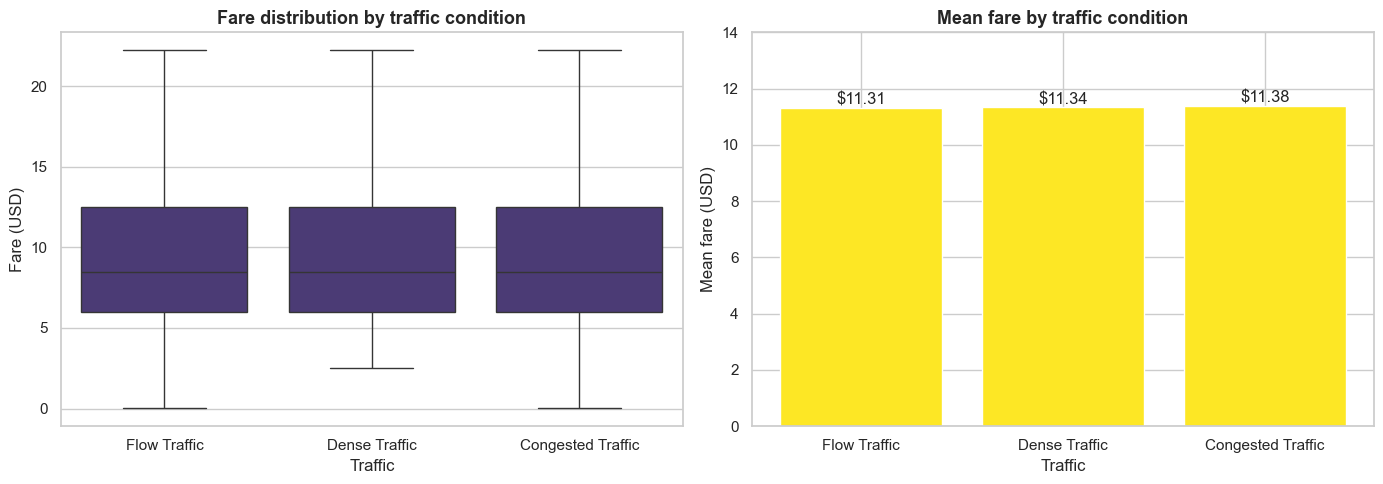

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ["Flow Traffic", "Dense Traffic", "Congested Traffic"]
sns.boxplot(data=df, x="traffic_condition", y="fare_amount", order=order,
            showfliers=False, ax=axes[0])
axes[0].set(title="Fare distribution by traffic condition",
            xlabel="Traffic", ylabel="Fare (USD)")

means = (df.groupby("traffic_condition", observed=True)["fare_amount"]
         .mean().reindex(order))
bars = axes[1].bar(means.index, means.values, color="#fde725")
axes[1].bar_label(bars, fmt="$%.2f")
axes[1].set(title="Mean fare by traffic condition",
            xlabel="Traffic", ylabel="Mean fare (USD)", ylim=(0, 14))
plt.tight_layout()
plt.show()

**Interpretation.** The physics said congestion should cost money; the data says these labels don't know about physics. Medians are identical ($8.50), and means span **$11.31 (Flow) to $11.38 (Congested)** — a 7-cent range on an $11 average. Row counts per level are again suspiciously equal (~160,700 each).

**Answer: no measurable effect** — strong evidence this column is synthetic like `car_condition`. A real traffic measurement would show a clear fare gap; its absence here is itself a finding worth reporting.

### Question 5 — Is trip distance the strongest predictor of the fare?

**Objective.** Taxi pricing is distance-metered, so `distance` should dominate. We want to confirm the relationship, measure its strength, and inspect its *shape* (linear? fanning? banded?) — the shape dictates model choice.

**Variables.**
- Independent: `distance` — numerical (km)
- Dependent: `fare_amount` — numerical (USD)

**Plot selection.** Two continuous numerics → **scatter plot**, the only choice that reveals the shape of the relationship (a correlation number can't distinguish a line from a curve from bands). On 480k rows a raw scatter is a solid smear, so we plot a 20k sample with transparency — a standard big-data scatter fix.

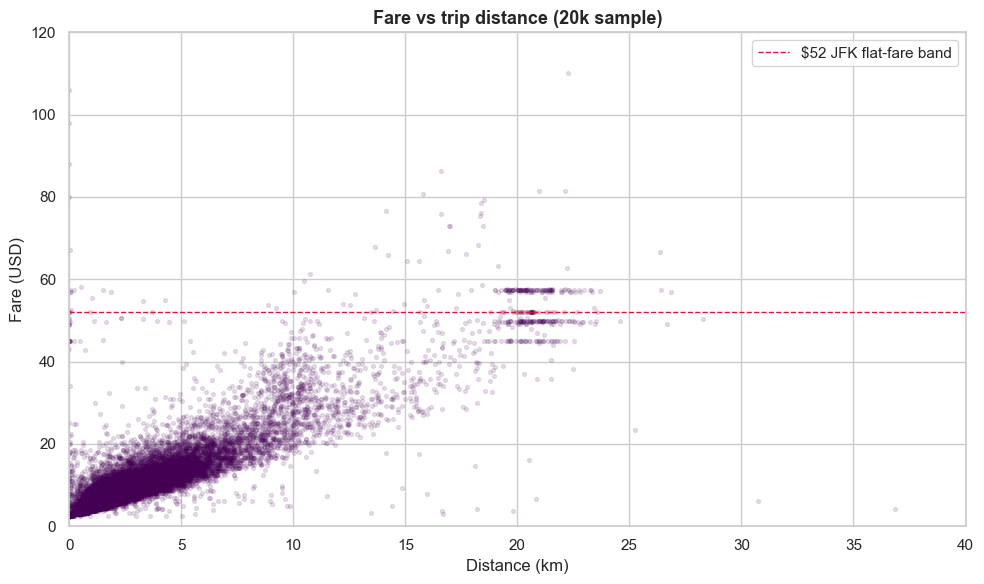

Pearson r : 0.863
Spearman  : 0.858


In [ ]:
sample = df.sample(SAMPLE, random_state=RNG)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample["distance"], sample["fare_amount"],
           alpha=0.12, s=8, color="#440154")
ax.axhline(52, color="crimson", ls="--", lw=1,
           label="$52 JFK flat-fare band")
ax.set(title="Fare vs trip distance (20k sample)",
       xlabel="Distance (km)", ylabel="Fare (USD)",
       xlim=(0, 40), ylim=(0, 120))
ax.legend()
plt.tight_layout()
plt.show()

print("Pearson r :", round(df["distance"].corr(df["fare_amount"]), 3))
print("Spearman  :", round(df["distance"].corr(df["fare_amount"],
                                               method="spearman"), 3))

**Interpretation.** A strong, tight, positive relationship: **Pearson r = 0.863** (Spearman 0.858 — the relationship is essentially linear, not just monotonic). Three details in the actual scatter matter:

1. **Positive intercept** — the point cloud does not pass through the origin; even near-zero distances cost a few dollars. That's the base fare, and it means a linear model *with* an intercept is the right functional family.
2. **Fan-out (heteroscedasticity)** — fare spread grows with distance: long trips vary by route, tolls, and waiting time. Expect larger errors on long trips.
3. **Horizontal banding around $52** (dashed line) — a dense stripe of long trips at *exactly* $52, which is the **NYC↔JFK flat fare** introduced in 2012 (854 trips over 15 km sit in that band, almost all from 2012 onward). Flat fares are distance-*independent* by construction — a source of irreducible error for any pure-distance model.

**Answer: yes** — distance is by far the strongest predictor (no other feature comes close; see the correlation heatmap in Section 6).

### Question 6 — At what time of day are ride requests most frequent?

**Objective.** Demand, not price: when do New Yorkers actually ride? (Deliberately distinct from Q3 — highest *fares* and highest *demand* need not coincide, and comparing the two curves is informative.)

**Variables.**
- Independent: `hour` — numerical discrete (0–23)
- Dependent: ride **count** (frequency)

**Plot selection.** Frequency of a discrete variable → **count plot / bar chart**. A line chart would also be defensible (hours are ordered), but bars emphasize the magnitude comparison between hours, which is the question. A histogram is technically the same picture here but with less control over tick alignment.

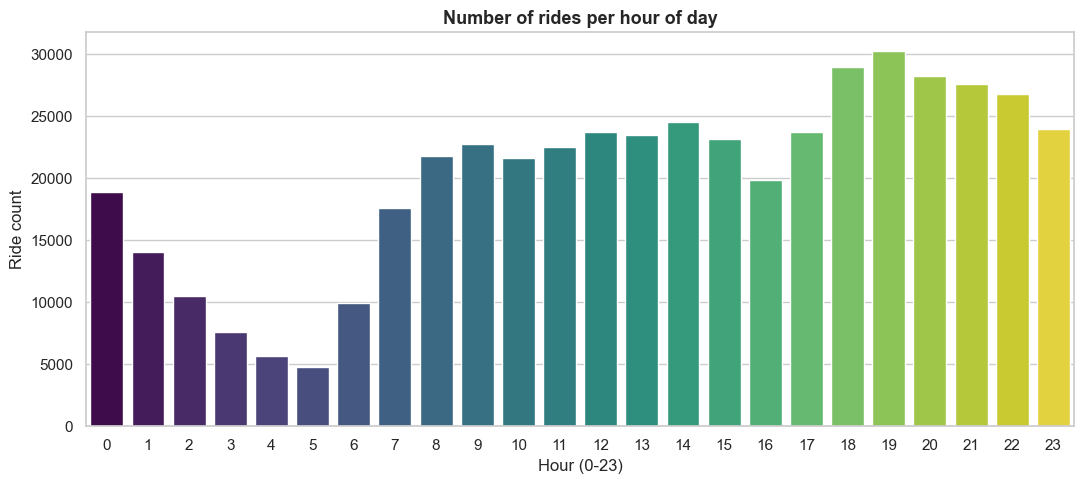

Peak: 19h with 30,266 rides | Trough: 5h with 4,784 rides


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.countplot(data=df, x="hour", hue="hour", legend=False,
              palette="viridis", ax=ax)
ax.set(title="Number of rides per hour of day",
       xlabel="Hour (0-23)", ylabel="Ride count")
plt.tight_layout()
plt.show()

counts = df["hour"].value_counts()
print(f"Peak: {counts.idxmax()}h with {counts.max():,} rides | "
      f"Trough: {counts.idxmin()}h with {counts.min():,} rides")

**Interpretation.** Demand follows the city's pulse: a deep overnight trough bottoming at **5 AM (4,784 rides)**, a morning ramp from 6–9 AM, a stable midday plateau (~22–24k), and a clear **evening peak at 7 PM (30,266 rides)** — commute plus dinner/social traffic — decaying slowly through the night.

Put next to Q3: demand and price are **inverted**. The 5 AM hour has the *fewest* trips but the *highest* average fare; 7 PM has the most trips at the *lowest* average fare. Nothing paradoxical — short frequent evening hops versus rare long dawn airport runs — but it proves you cannot infer price patterns from demand patterns.

**Answer:** demand peaks **18:00–20:00**, and is lowest at 4–5 AM.

### Question 7 — Does weather influence the average trip distance?

**Objective.** Behavioral hypothesis: in bad weather people take cabs for trips they'd otherwise walk (→ shorter average distance), or avoid travel entirely. If true, `weather` affects fare *indirectly* through distance.

**Variables.**
- Independent: `weather` — categorical (sunny / cloudy / windy / rainy / stormy)
- Dependent: `distance` — numerical (km)

**Plot selection.** Numeric across categories → **boxplot** again — but distance is heavily right-skewed (median 2.2 km, tail to 91 km), so untrimmed boxes would be flattened by outliers; we hide fliers and add a mean-per-group bar chart. A KDE per weather type is the alternative, but five overlapping skewed curves are hard to distinguish.

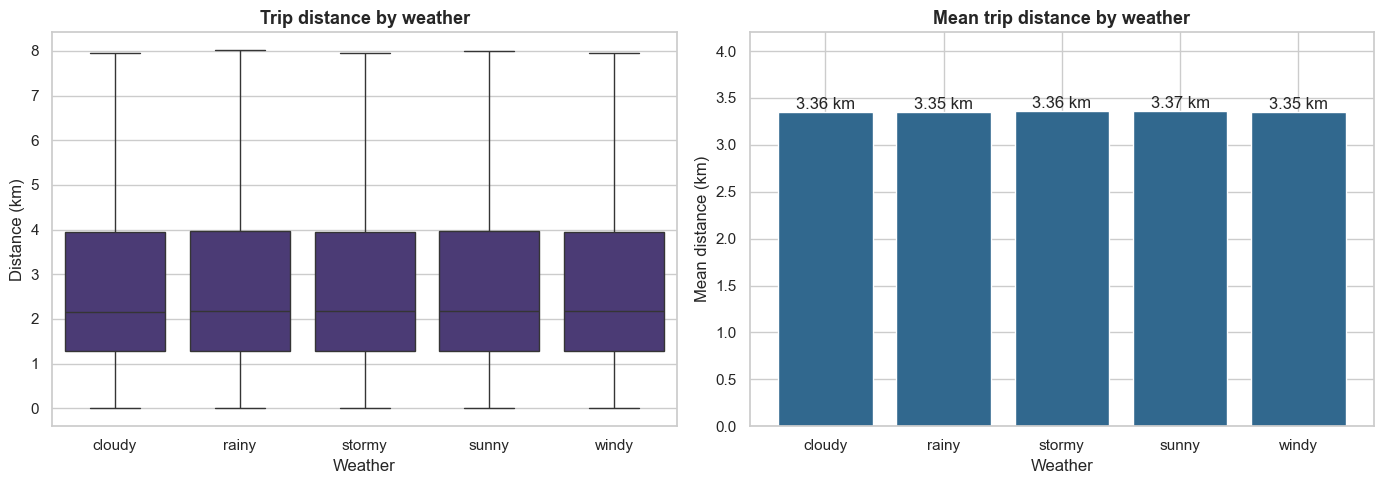

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="weather", y="distance",
            showfliers=False, ax=axes[0])
axes[0].set(title="Trip distance by weather",
            xlabel="Weather", ylabel="Distance (km)")

means = df.groupby("weather", observed=True)["distance"].mean()
bars = axes[1].bar(means.index.astype(str), means.values, color="#31688e")
axes[1].bar_label(bars, fmt="%.2f km")
axes[1].set(title="Mean trip distance by weather",
            xlabel="Weather", ylabel="Mean distance (km)", ylim=(0, 4.2))
plt.tight_layout()
plt.show()

**Interpretation.** Five identical boxplots. Mean distances range **3.350 km (windy) to 3.366 km (sunny)** — a 16-metre spread on a 3.4 km average. Medians all ≈ 2.18 km. And once more, every weather level has ~96,400 rows: a five-way uniform split that real NYC weather (which is *not* stormy 20% of the time) could never produce.

**Answer: no.** The behavioral hypothesis can't be tested with this column because the column is synthetic. `weather` joins `car_condition` and `traffic_condition` in the no-signal bucket — a consistent pattern across Q2/Q4/Q7 and one of the headline findings of this EDA.

### Question 8 — Are rides that start closer to airports more expensive?

**Objective.** Airports generate long, premium trips. If pickups near JFK/EWR/LGA carry systematically higher fares, the airport-distance features are valuable location encodings.

**Variables.**
- Independent: `jfk_dist`, `ewr_dist`, `lga_dist` — numerical (km from pickup to each airport)
- Dependent: `fare_amount` — numerical

**Plot selection.** Numeric vs numeric → **scatter plots**, one per airport, on shared axes so slopes are comparable. We overlay the sample's trend (correlations printed) and complement with a direct group comparison: mean fare for pickups *within 2 km* of each airport vs overall — because correlation over the whole city mixes many effects, while the near-airport group answers the business question head-on.

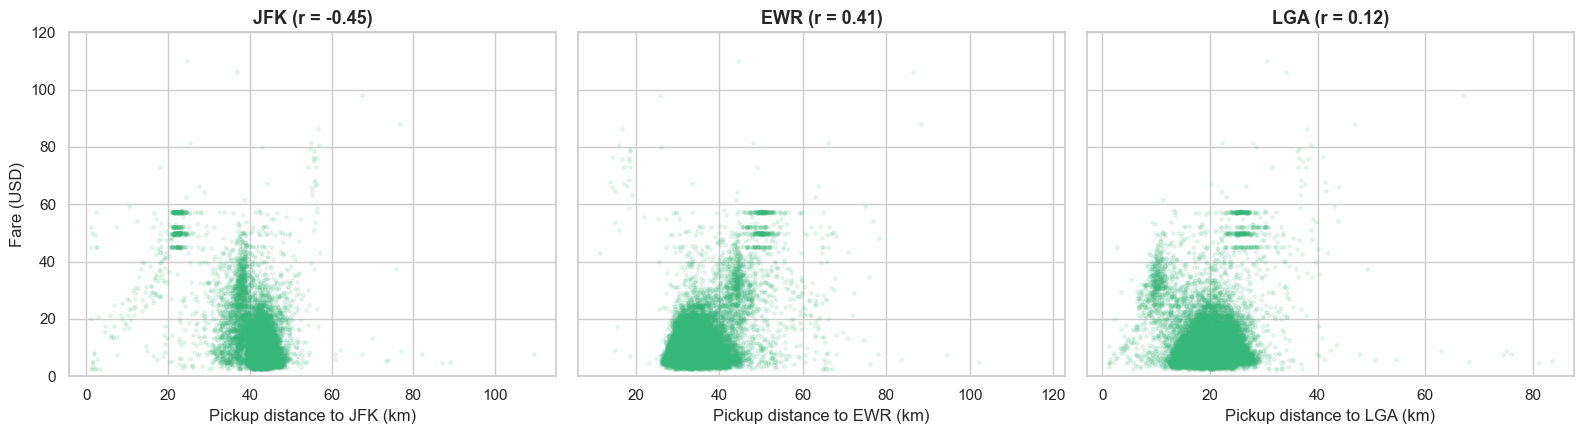

Airport   pickups < 2 km   mean fare
JFK                  205      23.67$
EWR                   14      71.95$
LGA                  122       9.51$
ALL              482,396      11.35$


In [ ]:
sample = df.sample(SAMPLE, random_state=RNG)
airports = [("jfk_dist", "JFK"), ("ewr_dist", "EWR"), ("lga_dist", "LGA")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (col, name) in zip(axes, airports):
    ax.scatter(sample[col], sample["fare_amount"],
               alpha=0.1, s=6, color="#35b779")
    r = df[col].corr(df["fare_amount"])
    ax.set(title=f"{name} (r = {r:.2f})",
           xlabel=f"Pickup distance to {name} (km)", ylim=(0, 120))
axes[0].set_ylabel("Fare (USD)")
plt.tight_layout()
plt.show()

print(f"{'Airport':<8}{'pickups < 2 km':>16}{'mean fare':>12}")
for col, name in airports:
    near = df[df[col] < 2]
    print(f"{name:<8}{len(near):>16,}{near['fare_amount'].mean():>11.2f}$")
print(f"{'ALL':<8}{len(df):>16,}{df['fare_amount'].mean():>11.2f}$")

**Interpretation.** The three panels look very different, and the correlations even have opposite signs — **JFK r = −0.45** (closer to JFK → higher fare) but **EWR r = +0.41** (closer to EWR → *lower*?). The resolution is geometric: most pickups are in Manhattan, JFK is far east, EWR is just west — so `jfk_dist` and `ewr_dist` are almost mirror images of each other. These features encode *where in the city you are*, not "airport-ness", and their correlations reflect city geography.

The near-airport group comparison is the honest answer: pickups within 2 km of **JFK average $23.67** — more than double the citywide $11.35 — and the 14 pickups near **EWR average $71.95** (New Jersey → NYC is a long haul). **LGA pickups average only $9.51**: LaGuardia sits close to Manhattan, so its trips are short.

**Answer: yes for JFK and EWR, no for LGA** — "airport" is not one phenomenon; it's proximity-dependent. The airport-distance features are useful, but as nonlinear location encodings, which favors tree-based models over raw linear terms.

## 6. Additional Insights — Self-Designed Questions

The submission checklist asks us to go beyond the given questions. Each of the ten below targets a decision we must make before modeling (target transformation, feature set, expected error structure).

### A1 — How is the target (`fare_amount`) distributed?

**Why interesting.** Everything downstream depends on the target's shape: a heavily skewed target breaks the error assumptions of linear models and makes RMSE dominated by a few huge fares. This decides whether we model `fare` or `log(fare)`.

**Plot.** **Histogram** — the canonical single-numeric-distribution plot — side by side on the raw and log scale. (A boxplot shows the outliers but not the shape; KDE hides the discreteness of common fare values.)

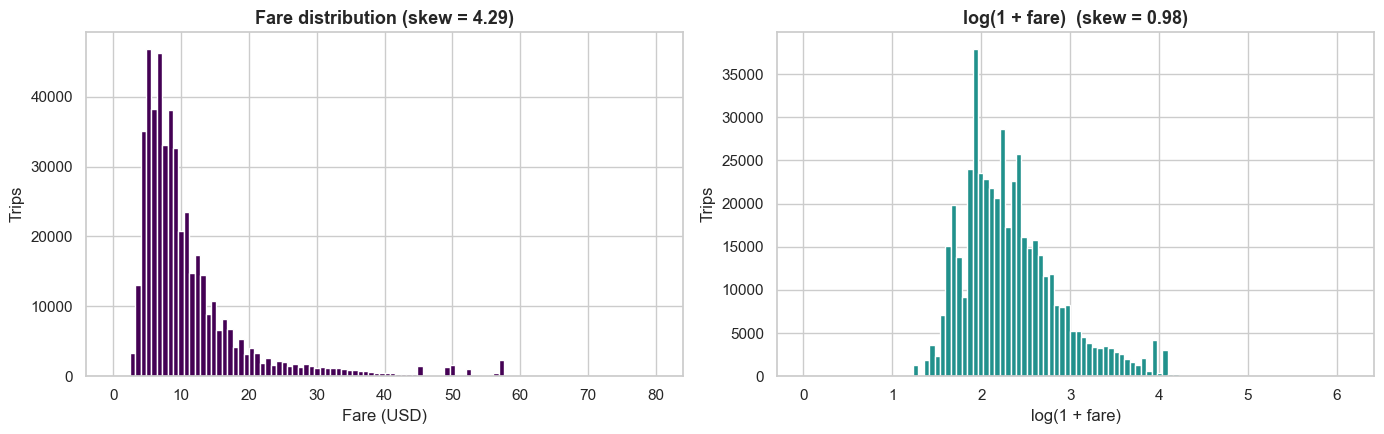

count    482396.00
mean         11.35
std           9.69
min           0.01
25%           6.00
50%           8.50
75%          12.50
95%          30.33
99%          52.00
max         450.00
Name: fare_amount, dtype: float64


In [ ]:
from scipy.stats import skew

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(df["fare_amount"], bins=100, range=(0, 80), color="#440154")
axes[0].set(title=f"Fare distribution (skew = {skew(df['fare_amount']):.2f})",
            xlabel="Fare (USD)", ylabel="Trips")

log_fare = np.log1p(df["fare_amount"])
axes[1].hist(log_fare, bins=100, color="#21918c")
axes[1].set(title=f"log(1 + fare)  (skew = {skew(log_fare):.2f})",
            xlabel="log(1 + fare)", ylabel="Trips")
plt.tight_layout()
plt.show()

print(df["fare_amount"].describe([.25, .5, .75, .95, .99]).round(2))

**Interpretation.** The raw distribution is textbook right-skewed (**skew = 4.3**): a sharp mode around $6–8, half of all trips under **$8.50**, 95% under $30 — yet a tail stretching to $450. The log transform collapses that tail beautifully (**skew drops to 0.98**), producing a near-symmetric bell.

**Consequence:** train on **log(fare)** (predict, then exponentiate back). This is the single highest-value transformation available in this dataset.

### A2 — When exactly is demand highest across the week?

**Why interesting.** Q6 gave the hourly profile averaged over all days — but Friday 11 PM and Tuesday 11 PM are different cities. The hour × weekday interaction reveals whether we need interaction features.

**Plot.** **Pivot heatmap** — the reference table's exact recommendation for two-variable (time × day) patterns. A line per weekday (7 overlapping lines) would be cluttered; the heatmap shows all 168 cells at once.

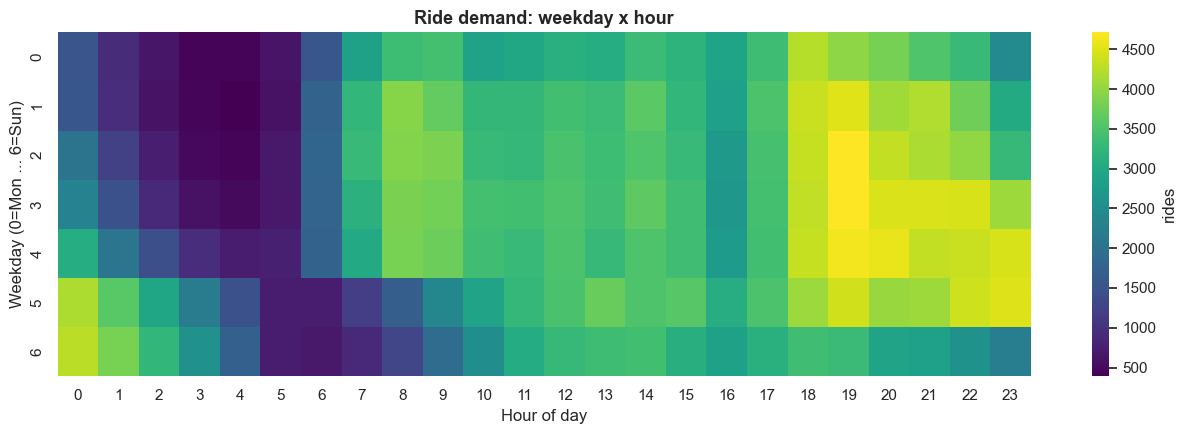

Busiest cell : (2, 19) 4,714 rides
Quietest cell: (1, 4) 390 rides


In [ ]:
demand = df.pivot_table(index="weekday", columns="hour",
                        values="key", aggfunc="count")

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(demand, cmap="viridis", ax=ax,
            cbar_kws={"label": "rides"})
ax.set(title="Ride demand: weekday x hour",
       xlabel="Hour of day", ylabel="Weekday (0=Mon ... 6=Sun)")
plt.tight_layout()
plt.show()

stacked = demand.stack()
print("Busiest cell :", stacked.idxmax(), f"{int(stacked.max()):,} rides")
print("Quietest cell:", stacked.idxmin(), f"{int(stacked.min()):,} rides")

**Interpretation.** The heatmap adds real structure that the averaged view hid:

- The single busiest cell is **Wednesday 7 PM (4,714 rides)**; the quietest is **Tuesday 4 AM (390)** — a 12× spread.
- A bright **late-night block on weekends**: rides between midnight and 2 AM on Saturday/Sunday (~10,700 and ~11,300) are 3–4× the same hours on Monday–Tuesday (~3,100) — Friday/Saturday nightlife spilling past midnight.
- The weekday morning rush (7–9 AM) simply doesn't exist on weekends; Saturday/Sunday mornings are dark until ~10 AM.

**Consequence:** hour and weekday **interact** — arguing for either an explicit `is_weekend_night` feature or a model class (trees) that learns interactions natively.

### A3 — Have fares risen over the years?

**Why interesting.** The data spans 2009–2015. If prices drifted upward, `year` is a necessary feature — otherwise the model averages 2009 and 2015 price levels and is systematically wrong at both ends.

**Plot.** **Line chart** (ordered time axis), with ride counts as context bars — because a trend computed on a shrinking sample deserves scrutiny.

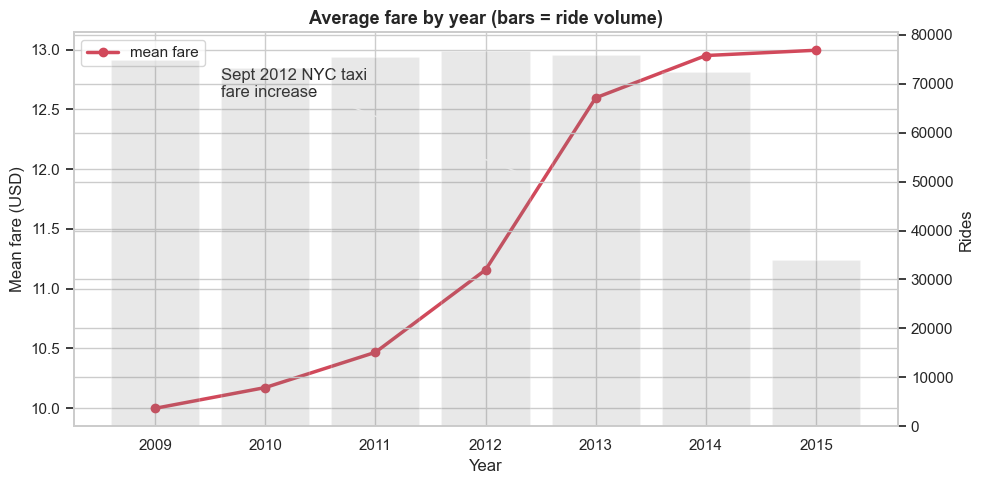

year
2009    10.00
2010    10.17
2011    10.47
2012    11.16
2013    12.60
2014    12.95
2015    13.00
Name: fare_amount, dtype: float64


In [ ]:
yearly = df.groupby("year")["fare_amount"].mean()
counts = df["year"].value_counts().sort_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax2.bar(counts.index, counts.values, alpha=0.18,
        color="grey", label="rides (right axis)")
ax1.plot(yearly.index, yearly.values, marker="o",
         color="#d1495b", lw=2.5, label="mean fare")
ax1.annotate("Sept 2012 NYC taxi\nfare increase",
             xy=(2012.5, 11.9), xytext=(2009.6, 12.6),
             arrowprops=dict(arrowstyle="->"))
ax1.set(title="Average fare by year (bars = ride volume)",
        xlabel="Year", ylabel="Mean fare (USD)")
ax2.set_ylabel("Rides")
ax1.legend(loc="upper left")
plt.tight_layout()
plt.show()
print(yearly.round(2))

**Interpretation.** Average fares climbed **30%** across the window: **$10.00 (2009) → $13.00 (2015)**. The rise is not smooth — the biggest single step is **2012 → 2013 (+$1.44)**, which matches reality: New York approved a ~17% taxi fare increase in **September 2012** (the same reform that set the $52 JFK flat fare seen in Q5 — and indeed the $52 band in our data only appears from 2012 onward). The grey bars flag one caveat: **2015 has only ~34k rides (half a year)** — the dataset ends mid-2015, so 2015's mean is computed on a partial, season-biased sample.

**Consequence:** keep `year` as a feature; without it the model can't know a 2009 trip and a 2015 trip are priced under different regimes.

### A4 — Which weekday generates the most rides?

**Why interesting.** Weekly seasonality of demand; also a sanity check that `weekday` behaves like real human activity (after three synthetic columns, healthy skepticism is warranted).

**Plot.** **Bar chart of counts** per weekday — seven ordered categories, frequency question.

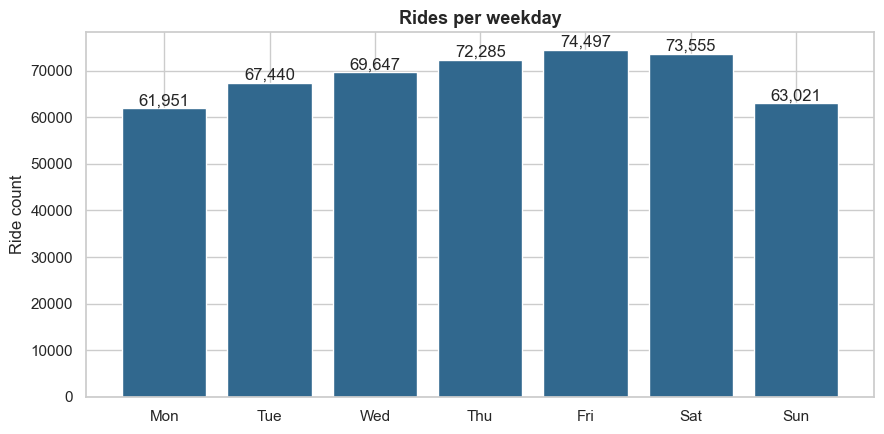

In [ ]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
wd = df["weekday"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(day_names, wd.values, color="#31688e")
ax.bar_label(bars, fmt="{:,.0f}")
ax.set(title="Rides per weekday", xlabel="", ylabel="Ride count")
plt.tight_layout()
plt.show()

**Interpretation.** A believable human rhythm: volume builds through the week to a **Friday peak (74,497)**, stays high Saturday (73,555), then drops to the weekly minimum on **Monday (61,951)** with Sunday nearly as quiet (63,021). The Friday/Monday gap is ~20%. (Mean fare by weekday, by contrast, moves only between $11.01 and $11.66 — day of week shifts *how many* trips happen far more than *what they cost*.)

**Consequence:** `weekday` matters for demand modeling; for fare prediction its direct effect is small but its interaction with hour (A2) is real.

### A5 — What does the trip-distance distribution look like?

**Why interesting.** Distance is our strongest predictor (Q5) — its shape tells us what typical trips are and whether distance itself needs transforming as a *feature*.

**Plot.** **Histogram** (single numeric distribution), zoomed to 0–25 km where 99.9% of the data lives, plus a log-scale count axis to keep the tail visible.

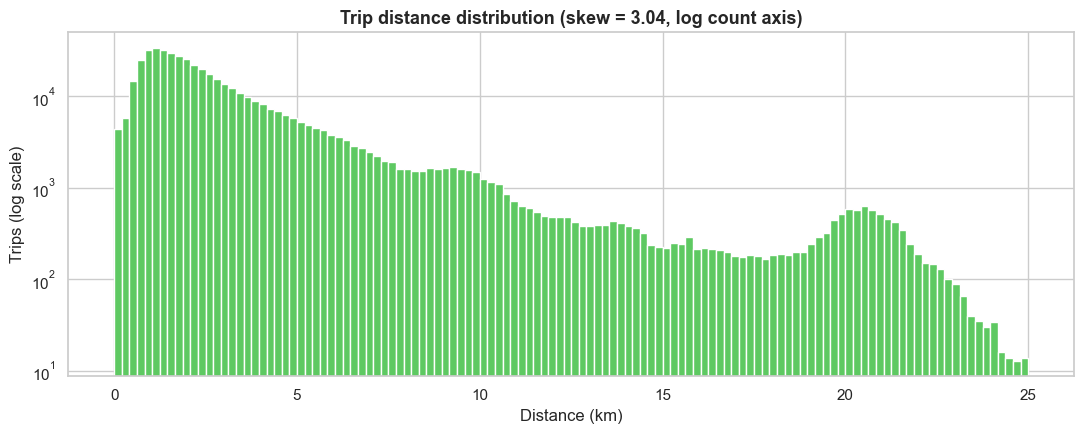

count    482396.00
mean          3.36
std           3.60
min           0.00
25%           1.28
50%           2.18
75%           3.96
95%          10.09
99%          20.31
max          91.23
Name: distance, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(df["distance"], bins=120, range=(0, 25), color="#5ec962")
ax.set_yscale("log")
ax.set(title=f"Trip distance distribution "
             f"(skew = {skew(df['distance']):.2f}, log count axis)",
       xlabel="Distance (km)", ylabel="Trips (log scale)")
plt.tight_layout()
plt.show()

print(df["distance"].describe([.25, .5, .75, .95, .99]).round(2))

**Interpretation.** Urban short-hop economics: the modal trip is **1–2 km**, the median **2.18 km**, three-quarters of all trips under 4 km. The distribution decays smoothly (skew 3.0) with a secondary thickening around **17–21 km — the Manhattan↔JFK corridor** — then a sparse tail to 91 km (far-suburb runs that survived the NYC bounding box, plausible and kept).

**Consequence:** most training signal concentrates on short trips; long trips are rare, expensive, and will dominate squared-error metrics — another argument for the log-target (A1), which balances their influence.

### A6 — Where in NYC are pickups concentrated?

**Why interesting.** The coordinate features feed distance-to-landmark features; seeing the actual spatial distribution validates the coordinate cleaning and shows what "location" means in this data.

**Plot.** **Geo scatter** of pickup longitude/latitude (the reference table's tool for spatial distribution) with heavy transparency so density reads as brightness — a poor-man's density map that needs no extra libraries.

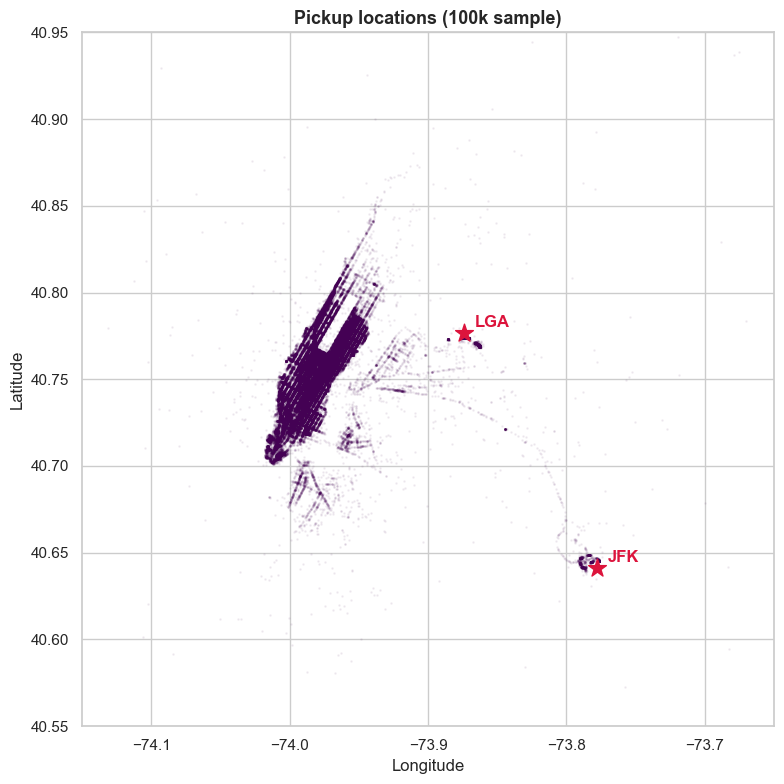

In [ ]:
sample = df.sample(100_000, random_state=RNG)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(sample["pickup_longitude"], sample["pickup_latitude"],
           s=1, alpha=0.05, color="#440154")
for lon, lat, name in [(-73.7781, 40.6413, "JFK"),
                       (-73.8740, 40.7769, "LGA"),
                       (-74.1745, 40.6895, "EWR")]:
    ax.scatter(lon, lat, marker="*", s=180, color="crimson", zorder=3)
    ax.annotate(name, (lon, lat), textcoords="offset points",
                xytext=(8, 4), color="crimson", weight="bold")
ax.set(title="Pickup locations (100k sample)",
       xlabel="Longitude", ylabel="Latitude",
       xlim=(-74.15, -73.65), ylim=(40.55, 40.95))
plt.tight_layout()
plt.show()

**Interpretation.** The scatter *draws Manhattan* — the dense dark spine running diagonally is the island itself, with density fading into Brooklyn and Queens. Two isolated bright clusters sit exactly on the **JFK** and **LGA** stars: airport queues. EWR (New Jersey) shows almost nothing — consistent with Q8's finding of only 14 near-EWR pickups. There are no points floating in the ocean or outside the metro area, confirming the bounding-box cleaning worked.

**Consequence:** location is highly structured — a handful of zones (Midtown, Downtown, two airports) generate most trips. Distance-to-landmark features are a sensible compression of this structure.

### A7 — What is the effective price per kilometre — and is it constant?

**Why interesting.** If fare were a pure per-km rate, fare/distance would be flat. Any structure in this ratio exposes the *pricing formula* — the mechanism we are trying to model.

**Plot.** **Line chart of median fare-per-km across distance bins.** A raw scatter of the ratio is dominated by short-trip noise; binning + median is robust. (We bin with `pd.cut`, which slices a numeric column into intervals.)

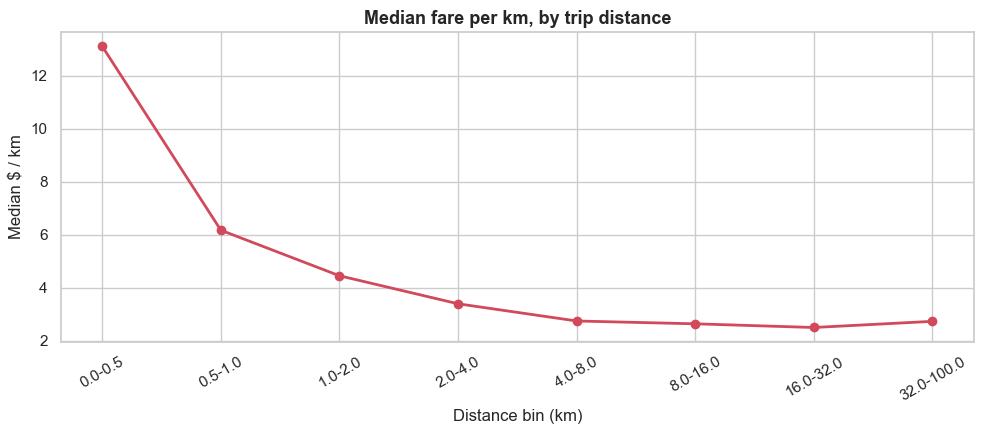

dist_bin
(0.0, 0.5]       13.10
(0.5, 1.0]        6.17
(1.0, 2.0]        4.45
(2.0, 4.0]        3.40
(4.0, 8.0]        2.75
(8.0, 16.0]       2.64
(16.0, 32.0]      2.50
(32.0, 100.0]     2.74
dtype: float64


In [ ]:
bins = [0, 0.5, 1, 2, 4, 8, 16, 32, 100]
df["dist_bin"] = pd.cut(df["distance"], bins)
rate = (df["fare_amount"] / df["distance"]).groupby(df["dist_bin"],
                                                    observed=True).median()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(range(len(rate)), rate.values, marker="o", color="#d1495b", lw=2)
ax.set_xticks(range(len(rate)),
              [f"{i.left}-{i.right}" for i in rate.index], rotation=30)
ax.set(title="Median fare per km, by trip distance",
       xlabel="Distance bin (km)", ylabel="Median $ / km")
plt.tight_layout()
plt.show()
print(rate.round(2))

**Interpretation.** A perfect hyperbola: trips under 0.5 km pay a median **$13.10/km**, falling steeply to **$4.45/km** at 1–2 km and flattening near **$2.50–2.75/km** beyond 8 km. This is exactly the signature of a **fixed base fare amortized over distance**: fare ≈ base + rate × km, so short trips carry the base charge on few kilometres.

**Consequence:** the pricing formula is affine, not proportional. Any linear model must include an intercept, and "fare per km" would be a *misleading* engineered feature — the raw (distance, fare) pair already encodes the formula correctly.

### A8 — Are night trips different from day trips?

**Why interesting.** Q3 hinted that hours differ through trip *composition*. We make it explicit with one binary cut — night (22:00–05:59) vs day — asking whether night trips are longer, pricier, or both. This tests a cheap engineered feature (`is_night`).

**Plot.** Side-by-side **bar comparisons** of mean fare and mean distance. (Two KDEs would show full distributions but the effect sizes here are small — bars with labels communicate the magnitudes honestly.)

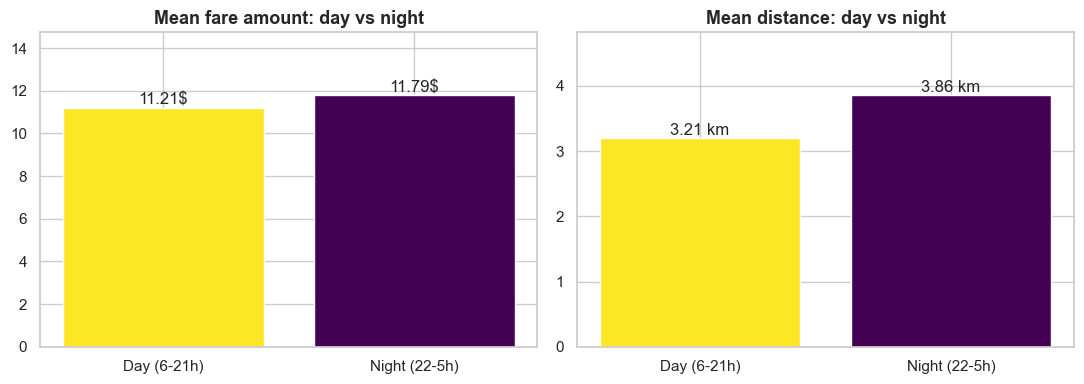

In [ ]:
df["is_night"] = df["hour"].isin([22, 23, 0, 1, 2, 3, 4, 5])
grp = df.groupby("is_night")[["fare_amount", "distance"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, unit in zip(axes, ["fare_amount", "distance"], ["$", " km"]):
    bars = ax.bar(["Day (6-21h)", "Night (22-5h)"], grp[col],
                  color=["#fde725", "#440154"])
    ax.bar_label(bars, fmt=f"%.2f{unit}")
    ax.set(title=f"Mean {col.replace('_', ' ')}: day vs night",
           ylim=(0, grp[col].max() * 1.25))
plt.tight_layout()
plt.show()

**Interpretation.** Night trips are both pricier (**$11.79 vs $11.21**, +5%) and meaningfully longer (**3.86 km vs 3.21 km**, +20%). The distance gap exceeding the fare gap is the interesting part: nights lose the short daytime errand trips (leaving longer journeys — airport runs, going home across boroughs), while the old $0.50 NYC night surcharge is too small to move an $11 average much.

**Consequence:** `is_night` is a real but modest feature; most of its information is already carried by `hour`. Worth keeping only if the model is linear (trees will find the cut themselves).

### A9 — Which numeric features correlate most with the fare?

**Why interesting.** One picture ranking all linear relationships at once — both with the target (feature importance intuition) and among features (redundancy/multicollinearity warnings for linear models).

**Plot.** **Correlation heatmap** — the reference table's tool for exactly this. Limitation acknowledged: Pearson captures only *linear* relationships, which is why the EDA above looked at shapes first.

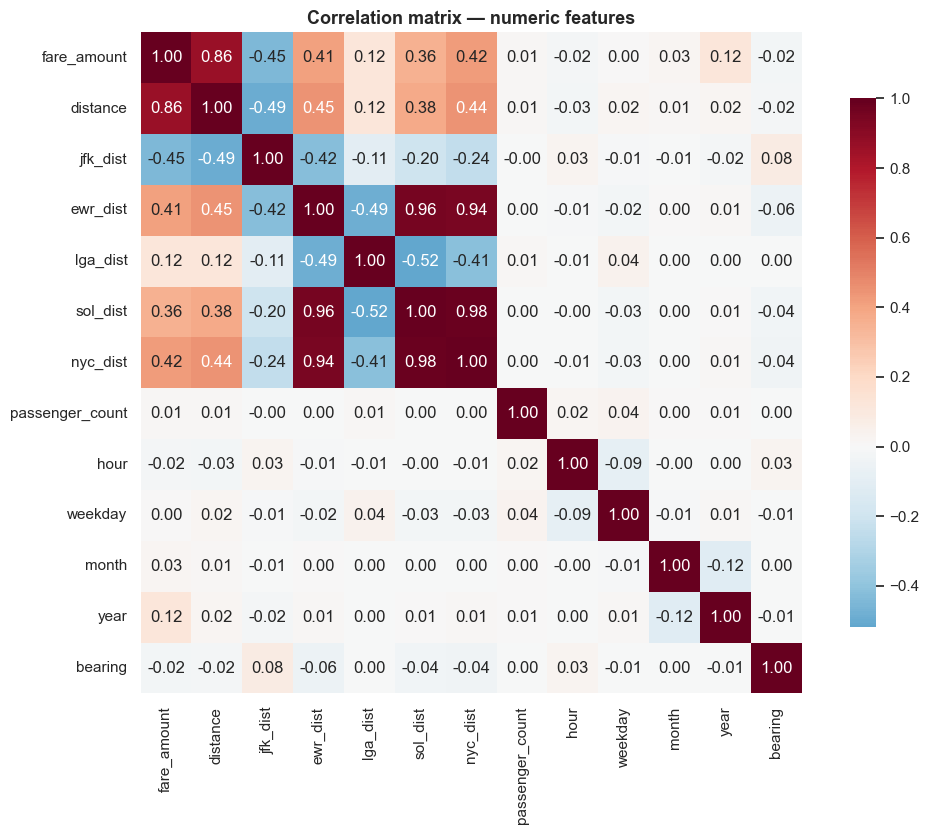

Correlation with fare_amount:
distance           0.863
jfk_dist          -0.448
nyc_dist           0.421
ewr_dist           0.411
sol_dist           0.357
year               0.119
lga_dist           0.117
month              0.025
bearing           -0.024
hour              -0.020
passenger_count    0.015
weekday            0.004
Name: fare_amount, dtype: float64


In [ ]:
num_cols = ["fare_amount", "distance", "jfk_dist", "ewr_dist",
            "lga_dist", "sol_dist", "nyc_dist", "passenger_count",
            "hour", "weekday", "month", "year", "bearing"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()

print("Correlation with fare_amount:")
print(corr["fare_amount"].drop("fare_amount")
      .sort_values(key=abs, ascending=False).round(3))

**Interpretation.** Reading the fare row: **distance dominates (0.86)**; a second tier of location encodings follows — `jfk_dist` (−0.45), `nyc_dist` (0.42), `ewr_dist` (0.41), `sol_dist` (0.36); then `year` (0.12, the price drift from A3); everything else — hour, weekday, month, passenger count, bearing — is ≤ |0.03| linearly.

The feature-feature block carries a warning: the landmark distances are **strongly inter-correlated** (e.g. `ewr_dist`–`sol_dist` ≈ 0.9+, `jfk_dist` vs `ewr_dist` strongly negative) because they all measure position in the same small city from different corners. For a linear model that multicollinearity destabilizes coefficients; tree ensembles shrug it off — one more reason the model recommendation (Section 7) is tree-based.

### A10 — What are the long trips (> 20 km), and can a distance-only model price them?

**Why interesting.** Long trips are 1.2% of rides but carry the largest fares and the largest squared errors — the segment where the model will win or lose its RMSE. And Q5 showed flat-fare bands live exactly here.

**Plot.** **Scatter of fare vs distance restricted to > 20 km**, with the $52 flat-fare line — zooming into the tail that the full-range scatter compressed.

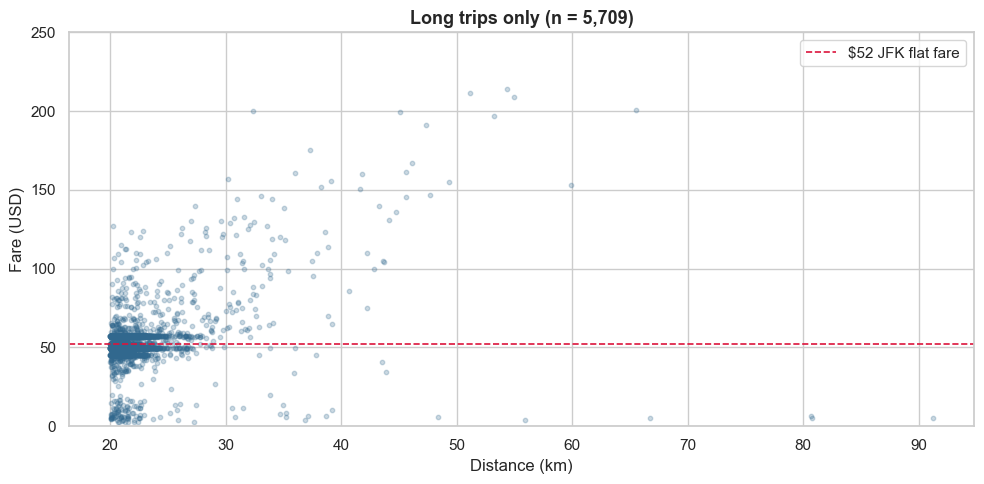

Share of all trips : 1.18%
Mean fare          : $53.29 (vs $11.35 overall)


In [ ]:
long_trips = df[df["distance"] > 20]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(long_trips["distance"], long_trips["fare_amount"],
           alpha=0.25, s=10, color="#31688e")
ax.axhline(52, color="crimson", ls="--", lw=1.2,
           label="$52 JFK flat fare")
ax.set(title=f"Long trips only (n = {len(long_trips):,})",
       xlabel="Distance (km)", ylabel="Fare (USD)", ylim=(0, 250))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Share of all trips : {len(long_trips) / len(df):.2%}")
print(f"Mean fare          : ${long_trips['fare_amount'].mean():.2f} "
      f"(vs ${df['fare_amount'].mean():.2f} overall)")

**Interpretation.** **5,709 trips (1.2%)** averaging **$53.29** — nearly 5× the overall mean. The scatter shows two regimes coexisting at the same distances: a rising metered cloud, and dense **horizontal shelves** around $52 and neighbouring values ($45/$50/$57 — flat fare with/without tolls) that ignore distance entirely. At 20–25 km, two identical trips can differ by $30 depending on whether a flat fare applied.

**Consequence:** this is *irreducible* error for a distance-only model. The features that could separate the regimes are the airport distances (a JFK-bound trip is flat-fare eligible) — a concrete, testable hypothesis for Task 2.

## 7. Feature Engineering Recommendations

Verdict on every column, grounded in the evidence above.

| Feature | Evidence | Decision |
|---|---|---|
| `distance` | r = 0.86, linear with intercept (Q5, A7) | **Keep** — primary feature |
| `jfk_dist`, `ewr_dist`, `lga_dist`, `sol_dist`, `nyc_dist` | second-tier correlations, nonlinear location encodings (Q8, A9) | **Keep** — best used by tree models; beware multicollinearity in linear ones |
| pickup/dropoff coordinates | validated, now in degrees (A6) | **Keep** — trees can learn zones directly; or keep only the engineered distances for linear models |
| `year` | +30% fare drift 2009→2015, 2012 fare hike (A3) | **Keep** — captures pricing regime |
| `hour` | shapes composition (Q3/Q6); cyclical | **Keep**; for linear models encode cyclically (sin/cos of 2πh/24) so hour 23 neighbours hour 0 |
| `weekday` | demand effect, hour interaction (A2, A4) | **Keep** — small direct fare effect; interactions matter |
| `month`, `week`, `day` | \|r\| ≤ 0.03; mild seasonality only | Keep `month` as candidate; `day` (of month) and `week` are near-duplicates of month — drop |
| `passenger_count` | r = 0.015, flat medians (Q1) | **Drop** (or keep for trees at near-zero cost) |
| `bearing` | r = −0.02; direction alone doesn't price trips | Drop for linear; optional for trees |
| `car_condition`, `weather`, `traffic_condition` | uniform counts, identical fare distributions (Q2/Q4/Q7) | **Drop** — synthetic, zero signal |
| `user_id`, `user_name`, `driver_name`, `key` | identifiers | **Drop** (PDF concurs) |
| `pickup_datetime` | fully decomposed into hour/weekday/month/year | Drop the raw timestamp after extraction |

**Target transformation:** model **log1p(fare_amount)** — skew falls 4.3 → 0.98 (A1), long-trip errors stop dominating the loss, and negative fare predictions become impossible after back-transform.

**New features worth creating for Task 2:**
- `dropoff_to_airport` distances (we only have *pickup*-to-airport — a trip *to* JFK is flat-fare eligible too; this directly targets the A10 shelves).
- `is_weekend_night` (A2's interaction, for linear models).
- Cyclical hour encoding (above).

**Model-family implication:** nonlinear location effects (Q8), feature interactions (A2), multicollinear distances (A9) and flat-fare regimes (A10) all point to **gradient-boosted trees** as the natural first serious model, with regularized linear regression on {log-distance, year, cyclical hour} as the honest baseline.

## 8. Final Conclusions

### Top 10 insights
1. **Distance explains most of the fare** — r = 0.86, the dominant predictor by a factor of ~2 over anything else.
2. **The fare is affine, not proportional**: a base fare plus per-km rate — $/km falls from $13.10 (sub-0.5 km hops) to ~$2.50 (long trips). Models need an intercept.
3. **Three categorical columns are synthetic**: `weather`, `traffic_condition`, `car_condition` show perfectly uniform level counts and zero effect on fare or distance. Real signal cannot be extracted from random labels.
4. **Fares rose 30% from 2009 to 2015**, with a visible step at the September 2012 NYC fare increase — `year` is a required feature.
5. **Flat-fare regimes exist**: dense $52 shelf (JFK flat fare, 2012+) among long trips — irreducible error for distance-only pricing, addressable with airport features.
6. **Demand and price are inverted across the day**: most rides at 7 PM (cheapest hour, $10.59 avg); fewest at 5 AM (dearest hour, $15.27 avg, driven by long airport runs).
7. **The target is heavily right-skewed** (skew 4.3); log1p normalizes it (0.98) — the highest-value modeling transformation available.
8. **Passenger count is irrelevant to fare** (r = 0.015; identical medians) — pricing is per-trip.
9. **Airport ≠ airport**: JFK-adjacent pickups average $23.67, EWR $71.95, but LGA only $9.51 — proximity effects are airport-specific and nonlinear.
10. **Demand has strong weekly structure**: Friday busiest (74.5k rides), Monday quietest (62k), with a weekend late-night block 3–4× weekday levels.

### Data quality observations
- 3.5% of rows removed, every removal physically justified (missing drop-offs, coordinates outside NYC, fares ≤ $0, zero passengers, zero distance).
- Coordinates and bearing arrive in **radians despite documentation saying degrees** — spec-vs-data mismatches must always be verified, never assumed.
- The categorical levels also contradict the documentation (5 weather levels, not 3) — same lesson.
- 2015 is a **partial year** (~34k rides); any yearly aggregate must account for it.

### Potential problems for modeling
- Heteroscedastic errors: fare variance grows with distance — expect worse absolute errors on long trips.
- Flat-fare bands put a floor on distance-based accuracy for the airport segment.
- Landmark-distance features are strongly multicollinear — hazardous for linear coefficient interpretation.
- The synthetic categoricals will show nonzero "importance" in a big tree model by pure noise-fitting — dropping them is cleaner than explaining them.

### Most important predictors of `fare_amount` (in order)
`distance` ≫ location encodings (`jfk_dist`, `nyc_dist`, `ewr_dist`, `sol_dist`) > `year` > `hour`/`weekday` (mainly via composition & interactions).

### Recommendations before modeling (Task 2)
1. Reuse this cleaning pipeline verbatim; freeze it as a function.
2. Model `log1p(fare)`; report errors in dollars after back-transform.
3. Add drop-off-to-airport distances and cyclical hour encoding.
4. Baseline: linear regression on {distance, year}; serious model: gradient-boosted trees on the full kept set.
5. Split train/test **by time** (e.g., train ≤ 2014, test 2015) — random splits leak the year-price drift and flatter the metrics.